In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import random

import numpy as np
import torch
import torch.distributions as TD
import torchvision.transforms as tr
from PIL import Image
from torchvision import datasets
from tqdm import tqdm

import wandb
from src.costs.lse import MLPLSECost
from src.costs.mlp_based import MLPCost
from src.models.energy_based import EGEOT
from src.plotting.distributions import plot_swiss_roll
from src.potentials.mlp_based import MLPPotential
from src.samplers.energy_based.sample_buffer import SampleBufferEgEOT
from src.samplers.from_dataset import DatasetSampler
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.utils.discrete_ot import OTPlanSampler
from src.utils.paired import generate_paired_data, get_GT_points, get_paired_sampler
from src.utils.train import compute_loss, update_average

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
# torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

## 2. Config

In [5]:
from configs.energy_based.cost import MLPCostConfig, MLPLSECostConfig, MLPL2CostConfig
from configs.energy_based.dataset import DatasetConfig, MiniBatchConfig
from configs.energy_based.model import EBMConfig
from configs.energy_based.optimizer import OptPairedConfig, OptUnpairedConfig
from configs.energy_based.potential import PotentialConfig
from configs.energy_based.sampling import LangevinConfig
from configs.energy_based.train import TrainConfig

In [6]:
Q_X_UNPAIRED_SAMPLES = 5958
R_Y_UNPAIRED_SAMPLES = 6131
P_XY_PAIRED_SAMPLES = 2000
IMG_SIZE = 32


LR_PAIRED = 1e-5
LR_UNPAIRED = 3e-5
SAMPLING_NUM_ITER = 500
MAX_STEPS = 100000
COST_FUNCTION = "MLP"
PAIRED_BATCH_SIZE = 256
UNPAIRED_BATCH_SIZE = 256

In [7]:
dataset_config = DatasetConfig(
    P_XY_paired=P_XY_PAIRED_SAMPLES, Q_X_unpaired=Q_X_UNPAIRED_SAMPLES, R_Y_unpaired=R_Y_UNPAIRED_SAMPLES
)
model_config = EBMConfig(sampling=LangevinConfig(num_iterations=SAMPLING_NUM_ITER))

opt_unpaired_config = OptUnpairedConfig(lr=LR_UNPAIRED)
opt_paired_config = OptPairedConfig(lr=LR_PAIRED)

train_config = TrainConfig(
    steps_to=MAX_STEPS, paired_batch_size=PAIRED_BATCH_SIZE, unpaired_batch_size=UNPAIRED_BATCH_SIZE
)

In [8]:
torch.manual_seed(train_config.seed)
np.random.seed(train_config.seed)
random.seed(train_config.seed)

## 3. Create data and samplers

In [9]:
from src.utils.dataset.colored_mnist import (
    apply_random_color,
    download_digit_images,
    get_paired_digits,
)

In [19]:
SOURCE_DATASET = "MNIST"
TARGET_DATASET = "MNIST"
SOURCE_DIGIT = 2
TARGET_DIGIT = 3
P_XY_PAIRED_SAMPLES = 5000

source_images: list[torch.Tensor] = download_digit_images(SOURCE_DATASET, SOURCE_DIGIT, 1000)
target_images: list[torch.Tensor] = download_digit_images(TARGET_DATASET, TARGET_DIGIT, 2000)

q_x_paired, q_y_paired = get_paired_digits(
    source_images, target_images, P_XY_PAIRED_SAMPLES, hue_offset=120, device=device
)

q_x = torch.stack([apply_random_color(digit, 360 * torch.rand(1)) for digit in source_images]).to(device)
q_y = torch.stack([apply_random_color(digit, 360 * torch.rand(1)) for digit in target_images]).to(device)

In [20]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..0.9529411764705884].


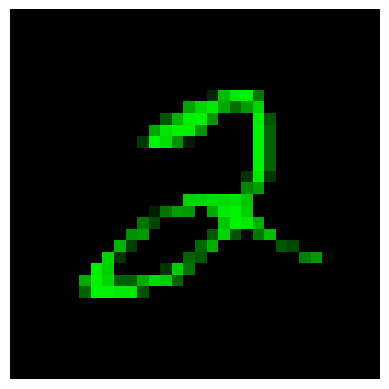

In [24]:
image_tensor = q_x_paired[0].roll(1, dims=0).permute(1, 2, 0)

# Plot the image
plt.imshow(image_tensor.detach().cpu().numpy())
plt.axis('off')  # Turn off axes for better visualization
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0..1.0].


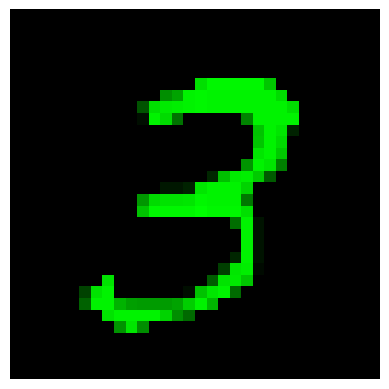

In [22]:
image_tensor = q_y_paired[0].permute(1, 2, 0)

# Plot the image
plt.imshow(image_tensor.detach().cpu().numpy())
plt.axis('off')  # Turn off axes for better visualization
plt.show()

In [17]:
pd_train_sampler = get_paired_sampler(
    paired_source_samples, paired_target_samples, train_config.paired_batch_size, dataset_config.P_XY_paired, device
)

In [18]:
if dataset_config.Q_X_unpaired > 0:
    usd_sampler = DatasetSampler(unpaired_source_samples, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(paired_source_samples, device=device)

if dataset_config.R_Y_unpaired > 0:
    utd_sampler = DatasetSampler(unpaired_target_samples, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(paired_target_samples, device=device)

## 4. Model initialization

In [20]:
from src.costs.convolutional import NonlocalCost, VanillaCost, UNetCost
from src.potentials.vanilla import NonlocalPotential, VanillaPotential

In [42]:
potential = VanillaPotential(n_f=IMG_SIZE) 

In [43]:
cost = UNetCost(n_c=3)

In [44]:
# TODO: add to config
BASIC_NOISE_VAR = 1.0
P_SAMPLE_BUFFER_REPLAY = 0.95
SAMPLE_BUFFER_SAMPLES = 10000

In [45]:
basic_noise_gen = TD.Normal(
    torch.zeros_like(unpaired_source_samples[0]).to(device),
    torch.ones_like(unpaired_source_samples[0]).to(device) * BASIC_NOISE_VAR,
)

sample_buffer_instance = SampleBufferEgEOT(
    basic_noise_gen, p=P_SAMPLE_BUFFER_REPLAY, max_samples=SAMPLE_BUFFER_SAMPLES, device=device
)

In [46]:
model = EGEOT(potential, cost, sample_buffer_instance, model_config)

In [47]:
# For EMA update
if train_config.ema_update:
    model_copy = EGEOT(potential, cost, sample_buffer_instance, model_config)

## 5. Optimizers initialization

In [68]:
from src.utils.dataset.colored_mnist import (
    apply_random_color,
    download_digit_images,
    get_paired_digits,
)

In [69]:
SOURCE_DATASET = "MNIST"
TARGET_DATASET = "MNIST"
SOURCE_DIGIT = 2
TARGET_DIGIT = 3

In [70]:
source_images[0].shape

torch.Size([28, 28])

In [73]:
import torchvision.transforms as transforms

In [100]:
transform = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)


data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)


indices = [i for i, label in enumerate(data.targets) if label == 3]

In [101]:
print([data[i][0] for i in indices[:2]])

[tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]]), tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])]


In [93]:
source_images[0].shape

torch.Size([1, 32, 32])

In [94]:
source_images: list[torch.Tensor] = download_digit_images(SOURCE_DATASET, SOURCE_DIGIT)
target_images: list[torch.Tensor] = download_digit_images(TARGET_DATASET, TARGET_DIGIT)

p_sampler = get_paired_digits(source_images, target_images, P_XY_PAIRED_SAMPLES, device=device)

q_x = torch.stack([apply_random_color(digit, 360 * torch.rand(1, device=digit.device)) for digit in source_images]).to(device)
q_y = torch.stack([apply_random_color(digit, 360 * torch.rand(1, device=digit.device)) for digit in target_images]).to(device)

In [51]:
q_x.shape, q_y.shape

(torch.Size([5958, 3, 28, 28]), torch.Size([6131, 3, 28, 28]))

In [52]:
q_y[:64].shape

torch.Size([64, 3, 28, 28])

In [59]:
model.potential.n_c

AttributeError: 'VanillaPotential' object has no attribute 'n_c'

In [95]:
model.potential.net(q_y[0])

tensor(-0.0080, device='cuda:0', grad_fn=<SqueezeBackward0>)

In [96]:
model.potential.grad_y(q_y[:64])

tensor([[[[-2.5119e-05, -3.7253e-05, -1.4675e-04,  ...,  4.8968e-05,
            2.3517e-05, -1.5665e-05],
          [-9.5699e-05, -6.4370e-05, -2.5400e-05,  ...,  5.8737e-05,
           -6.4172e-05, -4.3860e-05],
          [ 1.1917e-04, -1.1353e-04, -1.7890e-04,  ...,  3.4788e-05,
            1.4416e-04, -6.6733e-05],
          ...,
          [-3.4897e-05,  1.3572e-04, -8.3394e-05,  ..., -2.1190e-04,
            9.9322e-05, -1.9416e-05],
          [ 8.0671e-05, -7.3591e-05, -1.8766e-04,  ...,  7.5604e-05,
            1.0709e-04,  1.9152e-05],
          [-1.6559e-05, -3.4063e-05, -7.2426e-05,  ..., -1.2983e-04,
            1.5820e-05,  3.9650e-05]],

         [[ 1.3176e-05,  7.1369e-05,  1.3459e-05,  ..., -2.3111e-04,
           -7.4296e-05,  9.3558e-05],
          [-3.2655e-05, -1.3972e-05, -6.6017e-05,  ...,  3.7683e-05,
           -1.0383e-04,  5.5673e-06],
          [-1.2926e-04,  1.4741e-05, -1.4749e-04,  ...,  9.1197e-05,
            1.0618e-04,  9.8727e-05],
          ...,
     

In [20]:
D_opt_unpaired = torch.optim.Adam(model.potential.parameters(), **opt_unpaired_config.model_dump())

In [21]:
D_opt_paired = torch.optim.Adam(model.cost.parameters(), **opt_paired_config.model_dump())

In [22]:
# TODO: refactor this config
EXP_NAME = (
    "EgEOT_ColoredMNIST_"
    + f"COST_FUNCTION_{COST_FUNCTION}_"
    + f"P_XY_PAIRED_{dataset_config.P_XY_paired}_"
    + f"Q_X_UNPAIRED_{dataset_config.Q_X_unpaired}_"
    + f"R_Y_UNPAIRED_{dataset_config.R_Y_unpaired}_"
    + f"LR_PAIRED_{opt_paired_config.lr}_"
    + f"LR_UNPAIRED_{opt_unpaired_config.lr}_"
    + f"SAMPLING_STEPS_{model_config.sampling.num_iterations}_"
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    COST_FUNCTION=COST_FUNCTION,
    X_DIM=dataset_config.x_dim,
    Y_DIM=dataset_config.y_dim,
    D_LR_PAIRED=opt_paired_config.lr,
    D_LR_UNPAIRED=opt_unpaired_config.lr,
    BATCH_SIZE=train_config.unpaired_batch_size,
    P_XY_PAIRED_SAMPLES=dataset_config.P_XY_paired,
    Q_X_UNPAIRED_SAMPLES=dataset_config.Q_X_unpaired,
    R_Y_UNPAIRED_SAMPLES=dataset_config.R_Y_unpaired,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH, exist_ok=True)

In [23]:
if train_config.steps_from > 0:
    D_opt_unpaired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{train_config.steps_from}.pt")))
    D_opt_paired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_paired_{train_config.steps_from}.pt")))

## 6. Model training

In [ ]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(0, MAX_STEPS)):
    # training loop
    D_opt_unpaired.zero_grad()

    X = usd_sampler.sample(train_config.unpaired_batch_size)
    Y = utd_sampler.sample(train_config.unpaired_batch_size)

    output_unpaired = model.compute_unpaired_loss(X, Y, compute_stats=True)
    D_loss_unpaired = output_unpaired["loss"]

    wandb.log({f"Unpaired: Loss": D_loss_unpaired.item()}, step=step)
    wandb.log({f"Unpaired: \int f(y)": output_unpaired["int_potential"].item()}, step=step)
    wandb.log({f"Unpaired: \int\log Z": output_unpaired["int_log_Z"].item()}, step=step)
    wandb.log({f"Unpaired: -E(x, y)": output_unpaired["neg_energy_t"].item()}, step=step)
    wandb.log({f"Unpaired: c(x, y)": output_unpaired["cost_t"].item()}, step=step)
    wandb.log({f"Unpaired: f(y)": output_unpaired["potential_t"].item()}, step=step)
    wandb.log({f"Unpaired: noise": output_unpaired["noise"].item()}, step=step)

    D_opt_paired.zero_grad()
    X_paired, Y_paired = pd_train_sampler.sample(train_config.paired_batch_size)

    output_paired = model.compute_paired_loss(X_paired, Y_paired)
    D_loss_paired = output_paired["loss"]

    wandb.log({f"Paired: Loss": D_loss_paired.item()}, step=step)

    D_loss = D_loss_unpaired + D_loss_paired
    D_loss.backward()
    D_opt_paired.step()
    D_opt_unpaired.step()

    if train_config.ema_update:
        update_average(model_copy, model, 0.99)
        model = model_copy
    else:
        model = model

    wandb.log({f"Loss": D_loss}, step=step)

    if step % train_config.plot_every == 0:
        distr_dict = plot_samples(model, unpaired_source_samples, log=True)
        wandb.log(distr_dict)
        torch.save(model.state_dict(), os.path.join(OUTPUT_PATH, f"model_{step}.pt"))

torch.save(model.state_dict(), os.path.join(OUTPUT_PATH, f"D_{train_config.steps_to}.pt"))
torch.save(D_opt_paired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_paired_{train_config.steps_to}.pt"))
torch.save(D_opt_unpaired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{train_config.steps_to}.pt"))

wandb.finish()

wandb: Currently logged in as: muxaujl11110. Use `wandb login --relogin` to force relogin


  0%|                                                                                                                                                                                                 | 0/100000 [00:00<?, ?it/s]/trinity/home/m.persiyanov/miniconda3/envs/text/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1729647429097/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  0%|▍                                                                                                                                                                                  | 223/100000 [48:02<368:39:36, 13.30s/it]

## Plotting

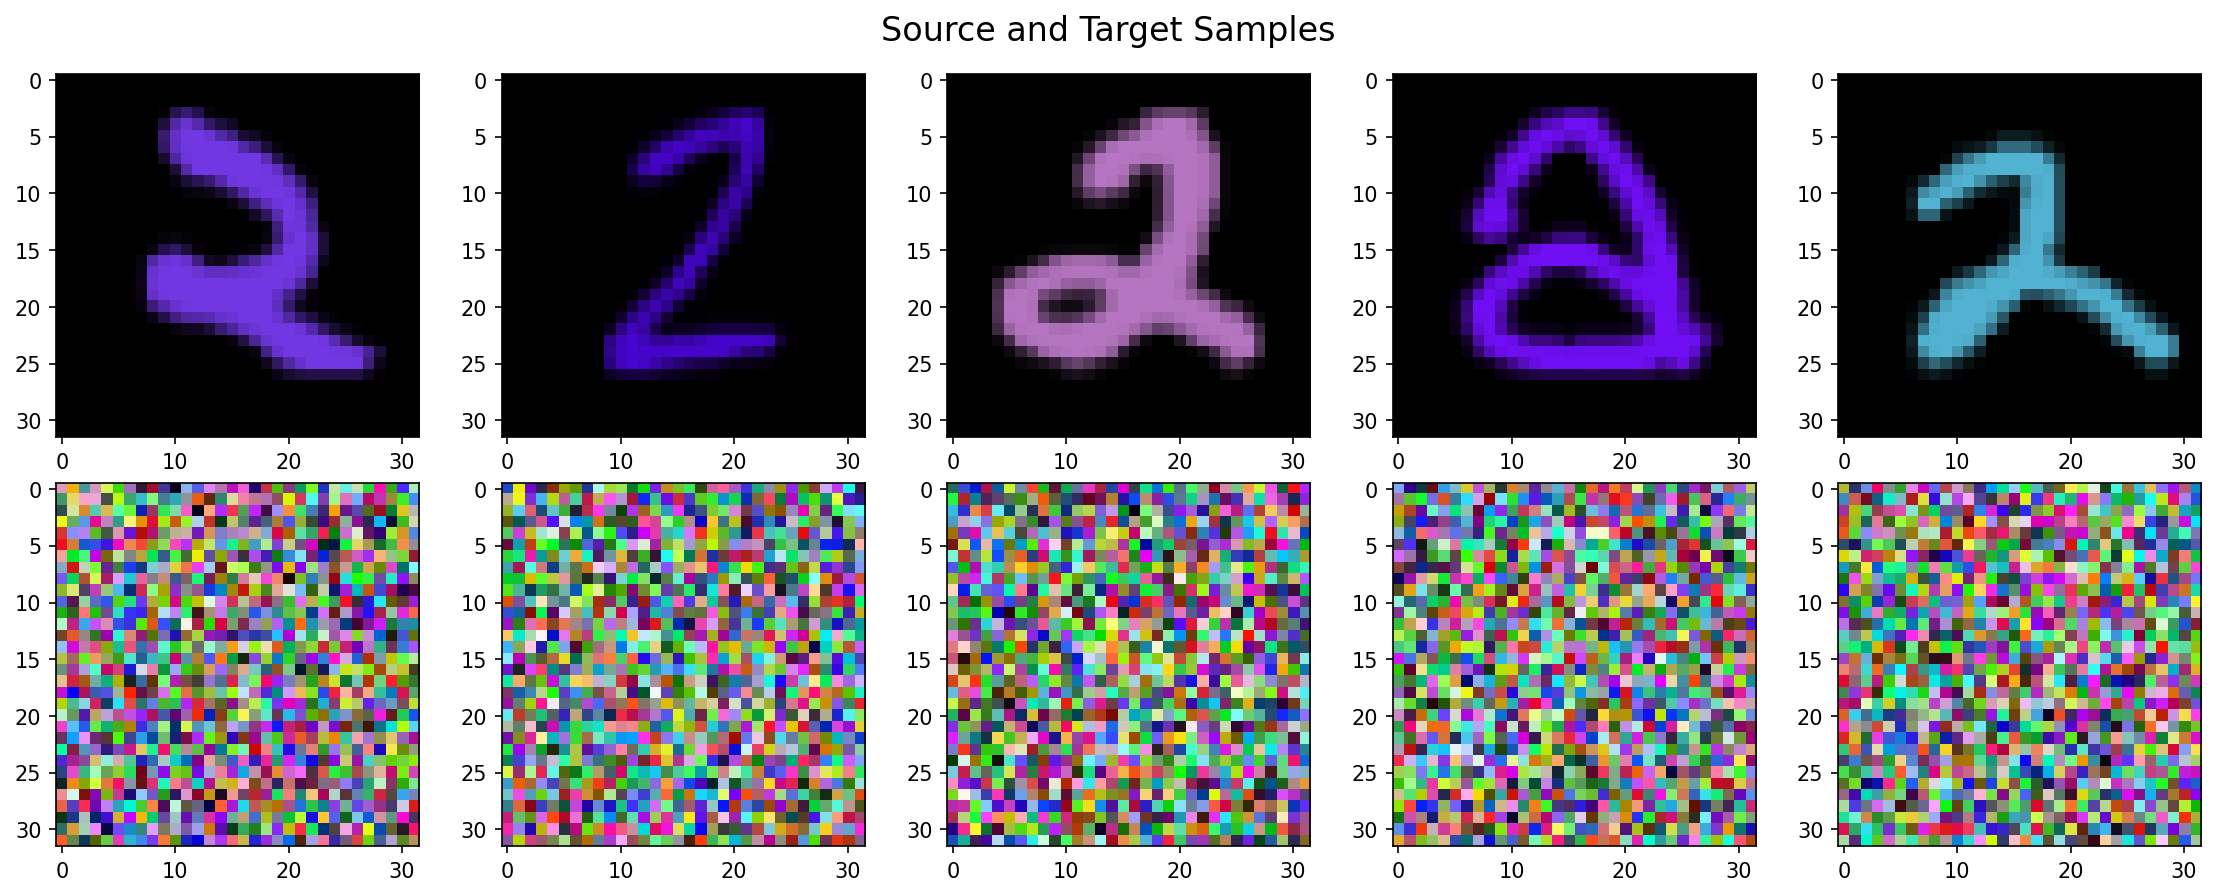

In [31]:
plot_samples(model, unpaired_source_samples)

  1%|█                                                                                                                                                                                | 572/100000 [2:03:10<382:16:40, 13.84s/it]